# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import numpy as np
from matplotlib import pyplot as plt

# Load data

In [3]:
from eyewire2_functional_analysis import data_loader

data_folder = "../../../data/preprocessed-data"
morph_folder = "../../../data/morphological-data"

In [4]:
print(sorted(os.listdir(morph_folder)))

['Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv', 'roi_mapping_2p_to_em.csv']


In [5]:
df_rois, df_fields, df_outline = data_loader.load_all_dfs(data_folder)

df = data_loader.load_df_rois_morph(
    morph_folder=morph_folder,
    morph_spreadsheet_filename='Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv',
    nuc_col_master='Final NucID',
    seg_col_master=(
        'Updated Seg ID\n(Feb 04, 2026)\nIF YOU UPDATE THIS COLUMN, ALSO UPDATE Final SegID!',
        'Updated Seg ID (Sept 2)',
        'Final SegID'),
    df_rois=df_rois,
)

In [6]:
[c for c in df.columns if 'ID' in c]

['Final NucID',
 'Box ID',
 'Final SegID',
 'Updated Nuc ID (Sept 2)',
 'Updated Seg ID (Sept 2)',
 'Cell Requires Review (DO NOT use Updated IDs for those cells)',
 'Updated Nuc ID\n(Feb 04, 2026)\nIF YOU UPDATE THIS COLUMN, ALSO UPDATE Final NucID!',
 'Updated Seg ID\n(Feb 04, 2026)\nIF YOU UPDATE THIS COLUMN, ALSO UPDATE Final SegID!',
 "Cell Requires Review \n(Feb 04, 2026)\n(don't use Updated IDs if this is True)\nDon't change to FALSE manually, setting to TRUE manually is ok",
 'Latest SegID']

# Plot data

In [7]:
row = df.iloc[0]

In [8]:
row.seg_id  # You can view this in neuroglancer

'720575940557124706'

In [9]:
chirp_time = np.arange(row.chirp_trace.size) * row.chirp_trace_dt + row.chirp_trace_t0
bar_time = np.arange(row.bar_trace.size) * row.bar_trace_dt + row.bar_trace_t0
mc_time = np.arange(row.mc_trace.size) * row.mc_trace_dt + row.mc_trace_t0

In [10]:
from eyewire2_functional_analysis.plot import plot_chirp, plot_bar

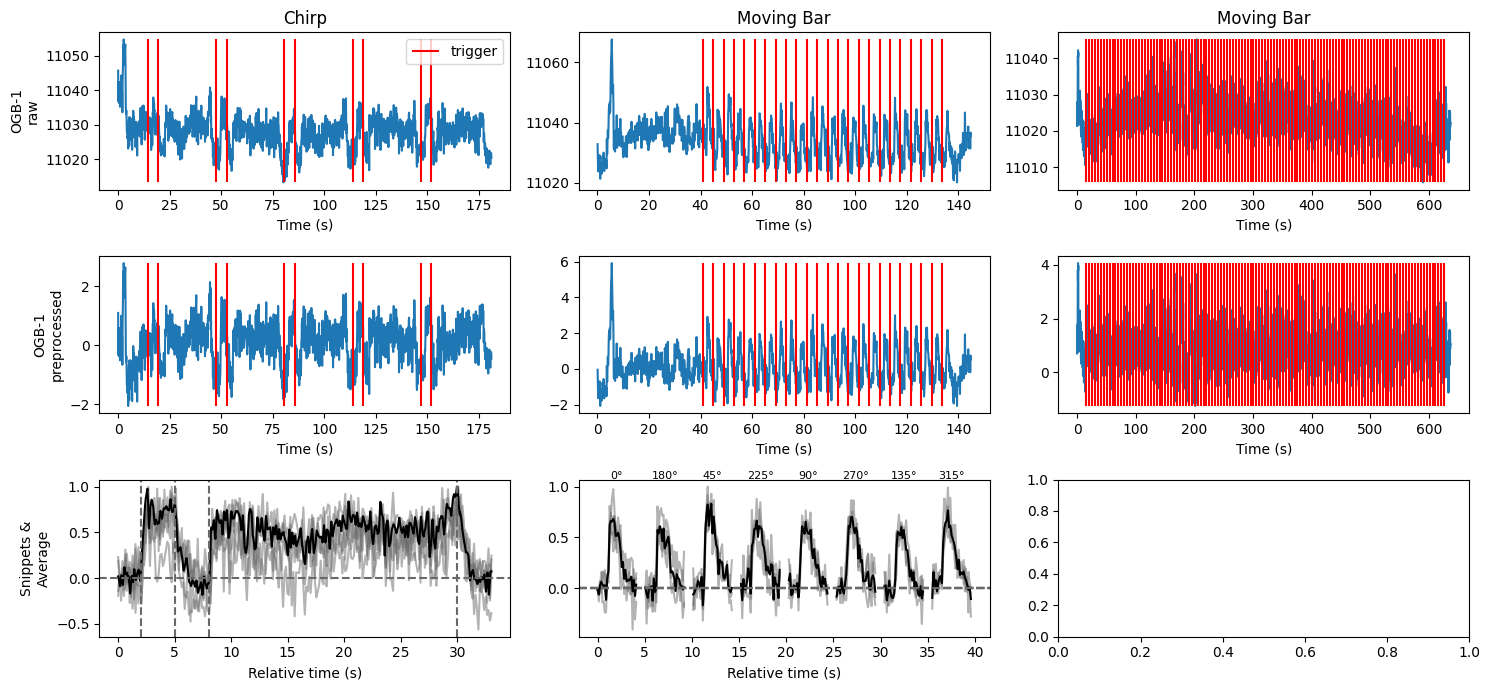

In [11]:
fig, axs = plt.subplots(3, 3, figsize=(15, 7))

# Raw
ax = axs[0, 0]
ax.plot(chirp_time, row.chirp_trace)
ax.vlines(row.chirp_triggertimes_snippets.flatten(), ymin=row.chirp_trace.min(), ymax=row.chirp_trace.max(), color='r',
          label='trigger')
ax.set(xlabel='Time (s)', ylabel='OGB-1\nraw', title='Chirp')
ax.legend(loc='upper right')

ax = axs[0, 1]
ax.plot(bar_time, row.bar_trace)
ax.vlines(row.bar_triggertimes_snippets.flatten(), ymin=row.bar_trace.min(), ymax=row.bar_trace.max(), color='r')
ax.set(xlabel='Time (s)', title='Moving Bar')

ax = axs[0, 2]
ax.plot(mc_time, row.mc_trace)
ax.vlines(row.mc_triggertimes.flatten(), ymin=row.mc_trace.min(), ymax=row.mc_trace.max(), color='r')
ax.set(xlabel='Time (s)', title='Moving Bar')

# Preprocessed
ax = axs[1, 0]
ax.plot(chirp_time, row.chirp_pp_trace)
ax.vlines(row.chirp_triggertimes_snippets.flatten(), ymin=row.chirp_pp_trace.min(), ymax=row.chirp_pp_trace.max(),
          color='r')
ax.set(xlabel='Time (s)', ylabel='OGB-1\npreprocessed')

ax = axs[1, 1]
ax.plot(bar_time, row.bar_pp_trace)
ax.vlines(row.bar_triggertimes_snippets.flatten(), ymin=row.bar_pp_trace.min(), ymax=row.bar_pp_trace.max(), color='r')
ax.set(xlabel='Time (s)')

ax = axs[1, 2]
ax.plot(mc_time, row.mc_pp_trace)
ax.vlines(row.mc_triggertimes.flatten(), ymin=row.mc_pp_trace.min(), ymax=row.mc_pp_trace.max(), color='r')
ax.set(xlabel='Time (s)')

# Average and repeats
ax = axs[2, 0]
plot_chirp(ax=ax, row=row, stimulus_ms=None, plot_hline=True, plot_vlines=True)
ax.set(xlabel='Relative time (s)', ylabel='Snippets &\nAverage')

ax = axs[2, 1]
plot_bar(ax=ax, row=row, annotate_dirs=True, annotate_symbols=False, ventral_up=True)
ax.set(xlabel='Relative time (s)')

plt.tight_layout()